# 085.PCA (Principal Component Analysis)

- PCA는 Karl Pearson이 1901 년에 발명한 통계 기법으로 직교 변환을 사용하여 변수 집합을 주성분이라고 하는 선형적으로 상관되지 않은 변수 집합으로 매핑.

- PCA는 원래 데이터세트의 공분산 행렬의 SVD(Singular Value Decomposition)를 기반으로 한다. 이러한 분해(decomposition)의 고유 벡터는 회전변환 행렬(rotation matrix)로 사용된다. 고유 벡터는 설명된 분산에 따라 내림차순으로 회전변환 행렬에 배열.

- PCA는 단순한 공간 변환, 차원 감소 및 스펙트럼 정보로부터의 혼합물 분리에 이르기까지 다양한 응용 분야에서 강력한 기술로 사용


- "ChurnData.csv"의 각 행은 고객을 나타내고 각 열은 고객의 속성 표시

- 데이터 세트에는 지난달에 탈회한 고객에 대한 정보가 포함 (Churn 1.0 - 탈회, 0.0 - 유지)

In [1]:
# 필요한 라이브러리 import
import numpy as np  # 수치 연산을 위한 라이브러리
import matplotlib.pyplot as plt  # 데이터 시각화를 위한 라이브러리
import pandas as pd  # 데이터프레임 처리를 위한 라이브러리
from sklearn.model_selection import train_test_split  # 학습/테스트 데이터 분리를 위한 함수
from sklearn.preprocessing import StandardScaler  # 데이터 정규화(표준화)를 위한 클래스
from sklearn.linear_model import LogisticRegression  # 로지스틱 회귀 모델
from sklearn.metrics import accuracy_score  # 정확도 평가 지표

In [2]:
# CSV 파일에서 고객 이탈 데이터 읽어오기
churn_df = pd.read_csv("datasets/ChurnData.csv")

In [3]:
# 데이터프레임의 처음 5개 행 확인 (데이터 구조 파악)
churn_df.head()

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,...,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,...,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,...,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,...,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,...,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0,0.0


In [4]:
# churn_df의 값을 numpy 배열로 변환
# pandas DataFrame을 numpy 배열로 변환하여 수치 연산에 활용
A = np.array(churn_df.values)
# 변환된 배열의 차원 확인 (행 개수, 열 개수)
A.shape

(200, 28)

In [5]:
# 마지막 열('churn')을 제외한 churn_df의 컬럼 이름들을 선택
# 마지막 열은 정답 레이블이므로 특성(feature)에서 제외
columns = churn_df.columns[:-1]
# 선택된 특성 컬럼의 개수 확인
columns.size

27

In [6]:
# 'columns'에 해당하는 모든 열을 선택하여 특성 데이터 X에 저장
X = churn_df.loc[:, columns]

# 'churn' 열을 정답 레이블 y에 저장
y = churn_df['churn']

In [7]:
# 데이터를 학습용과 테스트용으로 분리 (테스트 데이터는 전체의 20%)
# random_state=0으로 설정하여 실행 시마다 동일한 결과가 나오도록 고정
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [8]:
# StandardScaler 객체 생성 (데이터 정규화를 위한 전처리 도구)
sc = StandardScaler()

# 학습 데이터에 대해 평균과 표준편차를 계산하여 정규화 수행
X_train = sc.fit_transform(X_train)

# 테스트 데이터는 학습 데이터의 기준(평균, 표준편차)을 사용해 정규화
X_test = sc.transform(X_test)

In [9]:
# 정규화된 학습 데이터와 테스트 데이터의 차원 확인
print("학습 데이터 shape:", X_train.shape)
print("테스트 데이터 shape:", X_test.shape)

학습 데이터 shape: (160, 27)
테스트 데이터 shape: (40, 27)


### PCA 적용 전 Logistic Regression

- PCA 적용 후의 결과와 비교 목적

In [10]:
# 로지스틱 회귀 모델 생성
# solver='lbfgs': 최적화 알고리즘 설정 (작은 데이터셋에 적합)
# random_state=0: 결과 재현을 위해 랜덤 시드 고정
clf = LogisticRegression(solver='lbfgs', random_state=0)

# 학습 데이터를 사용하여 로지스틱 회귀 모델 훈련
clf.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [11]:
# 테스트 데이터셋에 대해 예측 수행
y_pred = clf.predict(X_test)

# 예측 결과에 대한 정확도(accuracy) 계산
# accuracy = (정답 맞춘 개수) / (전체 샘플 수)
# PCA 적용 전 원본 데이터로 학습한 모델의 정확도
print("PCA 적용 전 정확도:", accuracy_score(y_test, y_pred))

PCA 적용 전 정확도: 0.775


### PCA 적용

- 27 개의 feature 를 2 개로 차원 축소  


- components_
    - array, shape (n_components, n_features)
    - n_feature dimension 공간에서의 주성분 축  
    - data 의 분산을 최대로 보존하는 방향
    - explained_variance_ 에 순서대로 정렬되어 있음
    
- explained_variance_  
    - shape (n_components,)  
    - 선택한 각 구성 요소에서 설명하는 분산의 양  
    
- explained_variance_ratio_   
    - shape (n_components,)
    - 선택한 각 구성 요소가 설명하는 분산의 백분율입니다.

In [12]:
# PCA(주성분 분석)를 사용하여 차원 축소 수행
from sklearn.decomposition import PCA

# 주성분 개수를 2개로 설정 (2차원으로 축소하여 시각화 등에 활용 가능)
# n_components=2: 원본 27개 특성을 2개의 주성분으로 축소
pca = PCA(n_components=2)

# 학습 데이터에 대해 PCA를 학습하고 변환
# fit_transform: PCA 모델을 학습하고 동시에 데이터를 변환
# - 공분산 행렬 계산 및 고유값 분해 수행
# - 주성분 벡터 추출 및 데이터 투영
X_train_pca = pca.fit_transform(X_train)

# 테스트 데이터는 학습된 PCA 기준으로 변환만 수행
# transform: 학습된 PCA 모델을 사용하여 데이터만 변환 (재학습 없음)
X_test_pca = pca.transform(X_test)

In [13]:
# 차원 축소 결과 확인
# 원본: (샘플 수, 27) → 축소 후: (샘플 수, 2)
print("차원 축소된 X_train shape:", X_train_pca.shape)
print("차원 축소된 X_test shape:", X_test_pca.shape)

차원 축소된 X_train shape: (160, 2)
차원 축소된 X_test shape: (40, 2)


In [14]:
# 주성분의 구성 행렬(고유 벡터)의 shape 출력 → (주성분 개수, 원래 특성 개수)
# components_: 각 주성분이 원본 특성 공간에서 어떤 방향을 나타내는지 나타내는 행렬
print("주성분 행렬 shape:", pca.components_.shape)

# 첫 번째 주성분 벡터 출력 (원래 특성 공간에서의 방향)
# 첫 번째 주성분은 데이터의 분산을 가장 많이 설명하는 방향
print("첫번째 주성분(고유벡터):")
print(pca.components_[0])

# 두 번째 주성분 벡터 출력
# 두 번째 주성분은 첫 번째와 직교하며, 남은 분산을 가장 많이 설명하는 방향
print("두번째 주성분(고유벡터):")
print(pca.components_[1])

print()

# 각 주성분이 설명하는 분산의 비율(= 고유값 비율) 출력
# explained_variance_ratio_: 각 주성분이 전체 분산 중 얼마나 설명하는지 비율
# 두 성분의 합이 전체 분산 중 얼마를 설명하는지 확인
# 이 값이 높을수록 차원 축소 시 정보 손실이 적음
print('설명된 분산(고유값)의 비율: {}, 두 성분의 합: {:.2f}%'
      .format(pca.explained_variance_ratio_, sum(pca.explained_variance_ratio_) * 100))

주성분 행렬 shape: (2, 27)
첫번째 주성분(고유벡터):
[0.18870382 0.09407626 0.06999421 0.02405283 0.08039882 0.10532452
 0.0913006  0.22012759 0.24022929 0.17035807 0.26783154 0.16389682
 0.25017627 0.28326203 0.17638143 0.27435707 0.22993114 0.24062665
 0.26112415 0.0747603  0.22729268 0.21587761 0.06959358 0.17457864
 0.17900112 0.07082588 0.29324012]
두번째 주성분(고유벡터):
[ 0.2917276   0.18411246  0.24507417  0.04409899 -0.16349343  0.2142686
 -0.23252316  0.07599265 -0.23520159  0.29224485 -0.06742566 -0.24108039
  0.12944092 -0.20861384  0.29806582  0.04425842  0.22376079 -0.18866967
 -0.17737835 -0.24830636 -0.0674659  -0.05215805 -0.21541163  0.28738933
  0.03136523  0.07488121 -0.10196478]

설명된 분산(고유값)의 비율: [0.25193472 0.21764464], 두 성분의 합: 46.96%


In [15]:
# PCA로 차원 축소된 데이터를 사용하여 로지스틱 회귀 모델 생성
# solver='lbfgs': 최적화 알고리즘 설정 (작은 데이터셋에 적합한 quasi-Newton 방법)
# random_state=0: 결과 재현을 위한 시드 고정
clf = LogisticRegression(solver='lbfgs', random_state=0)

# 차원 축소된 학습 데이터를 사용해 모델 학습
# 27차원에서 2차원으로 축소된 데이터로 학습하므로 계산 속도가 빨라짐
clf.fit(X_train_pca, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [16]:
# 차원 축소된 테스트 데이터를 사용하여 예측 수행
# PCA로 변환된 2차원 데이터로 예측
y_pred = clf.predict(X_test_pca)
# 예측 결과 확인
y_pred

array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1., 0., 1., 1., 0., 0.,
       0., 0., 0., 0., 0., 0.])

In [17]:
from sklearn.metrics import accuracy_score

# 테스트 데이터에 대한 예측 결과와 실제 정답을 비교하여 정확도 계산
# PCA 적용 후 차원 축소된 데이터로 학습한 모델의 정확도
# PCA 적용 전 정확도와 비교하여 차원 축소가 성능에 미치는 영향 확인
pca_accuracy = accuracy_score(y_test, y_pred)
print("PCA 적용 후 정확도:", pca_accuracy)

PCA 적용 후 정확도: 0.725


## 차원 축소된 churn data 시각화
- 27 개의 feature 가 2 개의 PCA 로 차원 축소 되었으므로 평면상의 시각화 가능

In [18]:
# 차원 축소된 학습 데이터의 shape 확인
# 2차원으로 축소되어 시각화가 가능한 형태
X_train_pca.shape

(160, 2)

- 차원축소된 X_train_pca 를 X1, X2 축으로 시각화  

- y_train = 0, 1 을 color 로 구분

In [19]:
# y_train 값이 0인 샘플(즉, 비이탈 고객)에 해당하는 데이터만 선택
# 그 중 앞에서 5개 행만 출력하여 데이터 형태 확인
# 각 행은 [PCA1 값, PCA2 값] 형태의 2차원 좌표
X_train_pca[y_train == 0][:5]

array([[-1.79076917,  2.66110381],
       [-0.61237011,  2.69921328],
       [ 3.14274902,  4.7126509 ],
       [ 0.83536207,  2.1831414 ],
       [-1.00524582,  0.30330428]])

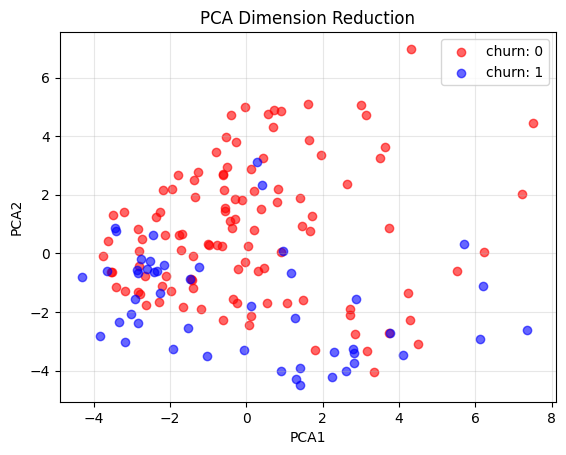

In [21]:
# 클래스 0에 대한 데이터를 분리하여 산점도로 표시
# y_train == 0: 고객 유지 (비이탈 고객)
# X1: 첫 번째 주성분 값, X2: 두 번째 주성분 값
X1, X2 = X_train_pca[y_train == 0, 0], X_train_pca[y_train == 0, 1]
plt.scatter(X1, X2, color='r', label="churn: 0", alpha=0.6)

# 클래스 1에 대한 데이터를 분리하여 산점도로 표시
# y_train == 1: 고객 이탈
X1, X2 = X_train_pca[y_train == 1, 0], X_train_pca[y_train == 1, 1]
plt.scatter(X1, X2, color='b', label="churn: 1", alpha=0.6)

# X축 라벨을 설정 (첫 번째 주성분)
plt.xlabel('PCA1')
# Y축 라벨을 설정 (두 번째 주성분)
plt.ylabel('PCA2')
# 범례를 표시
plt.legend()

# 그래프 제목 설정
plt.title('PCA Dimension Reduction')
# 격자 표시 (가독성 향상)
plt.grid(True, alpha=0.3)
plt.show()